In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenarios_and_methods import (
    generate_two_gaussian_abrupt_shift, generate_two_gaussian_slow_shift,
    generate_exchangeable_gaussian, generate_var1_dependence, generate_complex_dependence,
    risk_monitoring, plugin_martingale_test, simple_jumper_martingale_test,
    continuous_pairwise_betting_martingale_test,
    v_test, durbin_watson_test, yule_walker_test
)

# Perform tests

In [2]:
scenarios_dict = {
    "exchangeable": generate_exchangeable_gaussian,
    "two_gaussian_abrupt_shift": generate_two_gaussian_abrupt_shift,
    "generate_two_gaussian_slow_shift": generate_two_gaussian_slow_shift,
    "generate_var1_dependence": generate_var1_dependence,
    "generate_complex_dependence": generate_complex_dependence,
}

methods_dict = {
    "plugin_martingale": plugin_martingale_test,
    "jumper_martingale": simple_jumper_martingale_test,
    "continuous_pairwise_betting_martingale": continuous_pairwise_betting_martingale_test,
    'risk_monitoring': risk_monitoring,
    'v_test': v_test,
    'durbin_watson_test': durbin_watson_test,
    'yule_walker_test': yule_walker_test,
}

n_samples = 1000
n_runs = 10

result_list = []
for scenario_name, generate_data in scenarios_dict.items():
    for run in range(n_runs):
        # Regenerate data at each run to capture variability.
        is_exchangeable_ground_truth, X_to_test, y_to_test, X_train, y_train = generate_data(n_samples=n_samples)

        for method_name, method in methods_dict.items():
            is_exchangeable, threshold, test_stat = method(
                X_to_test=X_to_test,
                y_to_test=y_to_test,
                X_train=X_train,
                y_train=y_train,
            )
            df_ = pd.DataFrame({
                "scenario": scenario_name,
                "method": method_name,
                "run": run,
                "is_exchangeable_ground_truth": is_exchangeable_ground_truth,
                "is_exchangeable": is_exchangeable,
                "n": np.arange(1 if isinstance(test_stat, float) else len(test_stat)),
                "test_stat": test_stat,
                "threshold": threshold,
            })
            result_list.append(df_)

df = pd.concat(result_list, ignore_index=True)
df

Test accuracy: 0.890
Test accuracy: 0.907
Test accuracy: 0.927
Test accuracy: 0.880
Test accuracy: 0.870
Test accuracy: 0.900
Test accuracy: 0.867
Test accuracy: 0.890


/home/alecoz/Code/MAPIE/notebooks/echangeability_test/scenarios_and_methods.py:512: RuntimeWarning: invalid value encountered in scalar divide
  return num / denum


Test accuracy: 0.910


/home/alecoz/Code/MAPIE/notebooks/echangeability_test/scenarios_and_methods.py:512: RuntimeWarning: invalid value encountered in scalar divide
  return num / denum


Test accuracy: 0.913
Test accuracy: 0.987
Test accuracy: 0.997
Test accuracy: 0.990


...

/home/alecoz/Code/MAPIE/notebooks/echangeability_test/scenarios_and_methods.py:512: RuntimeWarning: invalid value encountered in scalar divide
  return num / denum


Test accuracy: 0.983
Test accuracy: 0.983
Test accuracy: 0.987
Test accuracy: 0.987
Test accuracy: 0.867
Test accuracy: 0.822


/home/alecoz/Code/MAPIE/notebooks/echangeability_test/scenarios_and_methods.py:512: RuntimeWarning: invalid value encountered in scalar divide
  return num / denum


Test accuracy: 0.800
Test accuracy: 0.856
Test accuracy: 0.778
Test accuracy: 0.789
Test accuracy: 0.767
Test accuracy: 0.722
Test accuracy: 0.811
Test accuracy: 0.822
Test accuracy: 0.567
Test accuracy: 0.556
Test accuracy: 0.522
Test accuracy: 0.556
Test accuracy: 0.611
Test accuracy: 0.544
Test accuracy: 0.544
Test accuracy: 0.611
Test accuracy: 0.656
Test accuracy: 0.578


,scenario,method,run,is_exchangeable_ground_truth,is_exchangeable,n,test_stat,threshold
0,exchangeable,plugin_martingale,0,True,1,0,1.000000,0.010000
1,exchangeable,plugin_martingale,0,True,1,1,1.000000,0.010000
2,exchangeable,plugin_martingale,0,True,1,2,0.980000,0.010000
3,exchangeable,plugin_martingale,0,True,1,3,0.956375,0.010000
4,exchangeable,plugin_martingale,0,True,1,4,0.918120,0.010000
...,...,...,...,...,...,...,...,...
175145,generate_complex_dependence,risk_monitoring,9,False,1,998,0.396794,0.565379
175146,generate_complex_dependence,risk_monitoring,9,False,1,999,0.396396,0.565379
175147,generate_complex_dependence,v_test,9,False,1,0,0.749000,0.050000
175148,generate_complex_dependence,durbin_watson_test,9,False,0,0,1.230550,1.000000


# Show results

In [3]:
# Aggregate one value per run (same within a run for all n)
run_level_df = (
    df.groupby(["scenario", "method", "run"])
    .agg(
        is_exchangeable_ground_truth=("is_exchangeable_ground_truth", "first"),
        is_exchangeable=("is_exchangeable", "first"),
    )
    .reset_index()
)

# Mean/std over runs per scenario/method
summary_df = (
    run_level_df.groupby(["scenario", "method"])
    .agg(
        is_exchangeable_ground_truth=("is_exchangeable_ground_truth", "first"),
        is_exchangeable_mean=("is_exchangeable", "mean"),
        is_exchangeable_std=("is_exchangeable", "std"),
    )
    .reset_index()
)
summary_df["is_exchangeable_std"] = summary_df["is_exchangeable_std"].fillna(0.0)

# Format table entries as "mean +- std"
summary_df["mean_std"] = summary_df.apply(
    lambda row: f"{row['is_exchangeable_mean']:.2f} +- {row['is_exchangeable_std']:.2f}",
    axis=1,
)

# Build display table
table_df = summary_df.pivot(index="scenario", columns="method", values="mean_std")
gt_df = summary_df[["scenario", "is_exchangeable_ground_truth"]].drop_duplicates()
gt_df = gt_df.rename(columns={"is_exchangeable_ground_truth": "ground_truth"})
final_table_df = table_df.join(gt_df.set_index("scenario"))

# Reorder rows/columns
final_table_df = final_table_df.loc[[s for s in scenarios_dict]]
cols = ["ground_truth"] + [col for col in final_table_df.columns if col != "ground_truth"]
final_table_df = final_table_df[cols]
display(final_table_df)

,ground_truth,continuous_pairwise_betting_martingale,durbin_watson_test,jumper_martingale,plugin_martingale,risk_monitoring,v_test,yule_walker_test
scenario,,,,,,,,
exchangeable,True,0.80 +- 0.42,1.00 +- 0.00,1.00 +- 0.00,1.00 +- 0.00,1.00 +- 0.00,0.50 +- 0.53,1.00 +- 0.00
two_gaussian_abrupt_shift,False,0.70 +- 0.48,0.80 +- 0.42,0.00 +- 0.00,0.80 +- 0.42,0.00 +- 0.00,0.40 +- 0.52,0.00 +- 0.00
generate_two_gaussian_slow_shift,False,0.40 +- 0.52,0.80 +- 0.42,0.00 +- 0.00,0.50 +- 0.53,0.00 +- 0.00,0.30 +- 0.48,0.00 +- 0.00
generate_var1_dependence,False,0.90 +- 0.32,0.00 +- 0.00,0.70 +- 0.48,1.00 +- 0.00,1.00 +- 0.00,0.30 +- 0.48,0.00 +- 0.00
generate_complex_dependence,False,1.00 +- 0.00,0.00 +- 0.00,0.00 +- 0.00,0.60 +- 0.52,1.00 +- 0.00,0.60 +- 0.52,0.00 +- 0.00


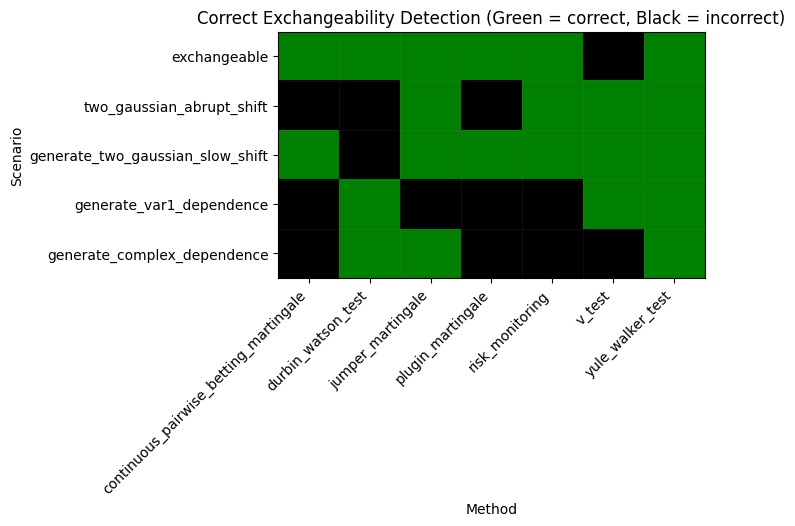

In [4]:
# Create a small grid plot summarizing correctness per scenario/method
# A method predicts exchangeability with majority vote over runs:
# is_exchangeable_pred = mean(is_exchangeable) > 0.5
pred_df = summary_df.copy()
pred_df["is_exchangeable_pred"] = pred_df["is_exchangeable_mean"] > 0.5

fig, ax = plt.subplots(figsize=(2 + 0.5 * (len(cols) - 1), 0.7 + 0.5 * len(final_table_df)))
grid = []

for scenario in final_table_df.index:
    row = []
    gt_value = bool(gt_df.set_index("scenario").loc[scenario, "ground_truth"])
    for method in cols[1:]:
        pred_value = bool(
            pred_df[
                (pred_df["scenario"] == scenario) & (pred_df["method"] == method)
            ]["is_exchangeable_pred"].iloc[0]
        )
        correct = pred_value == gt_value
        row.append(1 if correct else 0)
    grid.append(row)
grid = np.array(grid)

# show as colored squares: green for correct, black for incorrect
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["black", "green"])
ax.imshow(grid, cmap=cmap, aspect="auto")

# Set ticks and labels
ax.set_xticks(np.arange(len(cols) - 1))
ax.set_yticks(np.arange(len(final_table_df.index)))
ax.set_xticklabels(cols[1:], rotation=45, ha="right")
ax.set_yticklabels(final_table_df.index)
ax.set_xlabel("Method")
ax.set_ylabel("Scenario")
ax.set_title("Correct Exchangeability Detection (Green = correct, Black = incorrect)")

# Minor grid for clarity
ax.set_xticks(np.arange(-0.5, len(cols) - 1, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(final_table_df.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.15)
ax.tick_params(which="minor", length=0)

plt.show()

# Plot stats over time

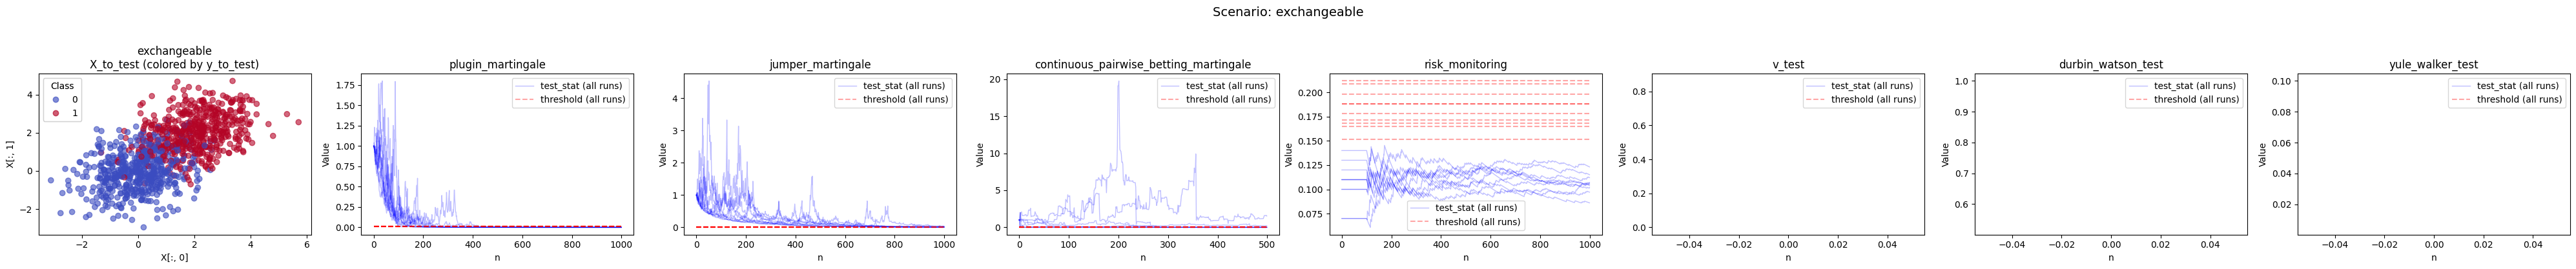

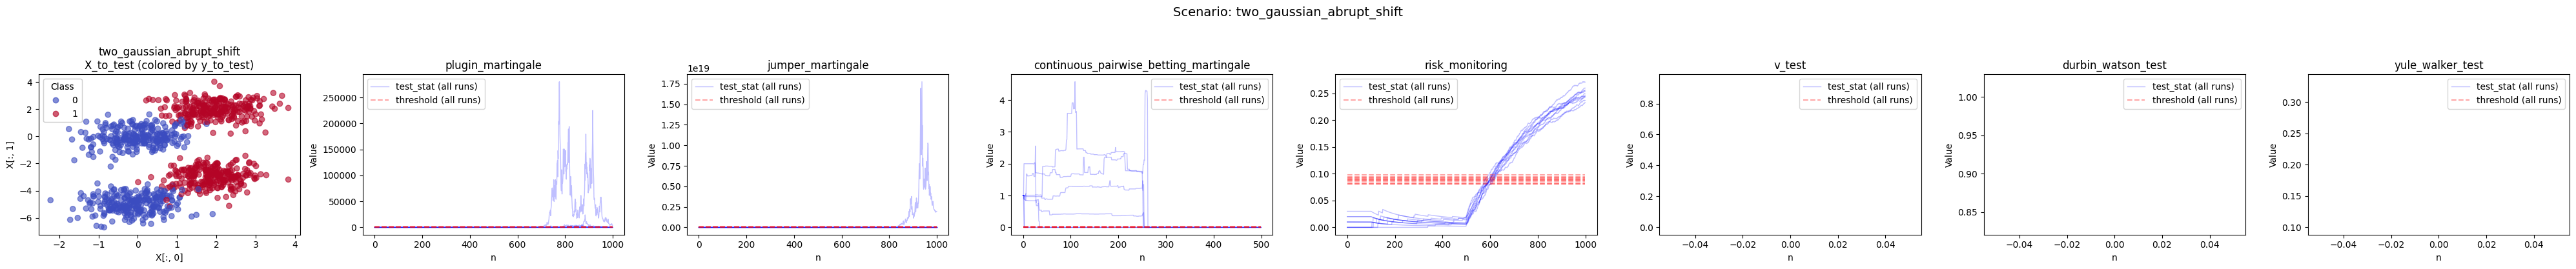

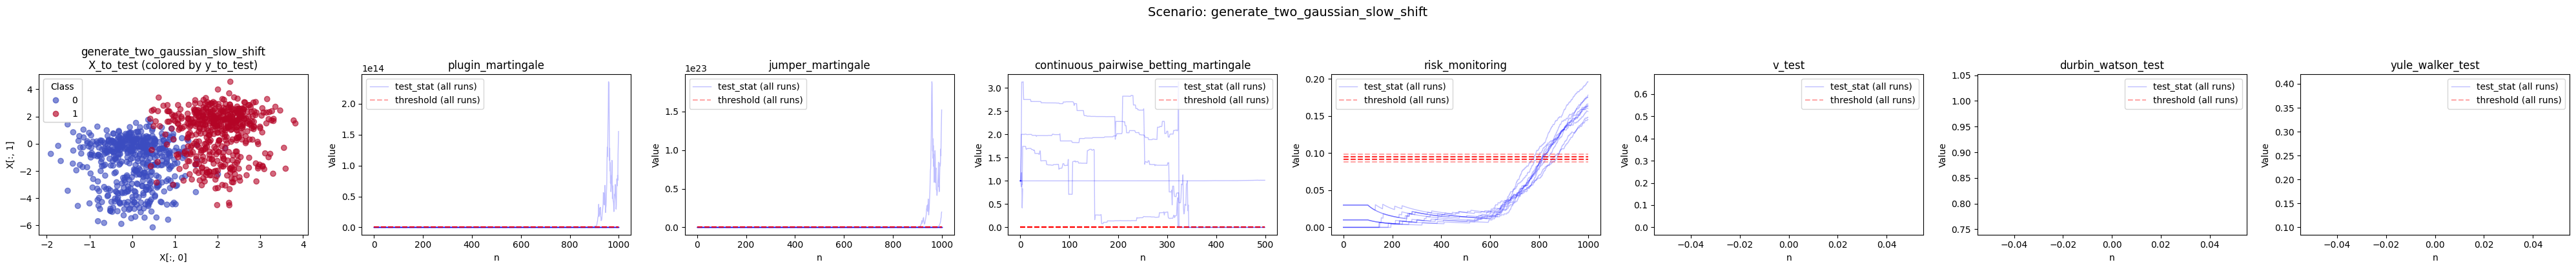

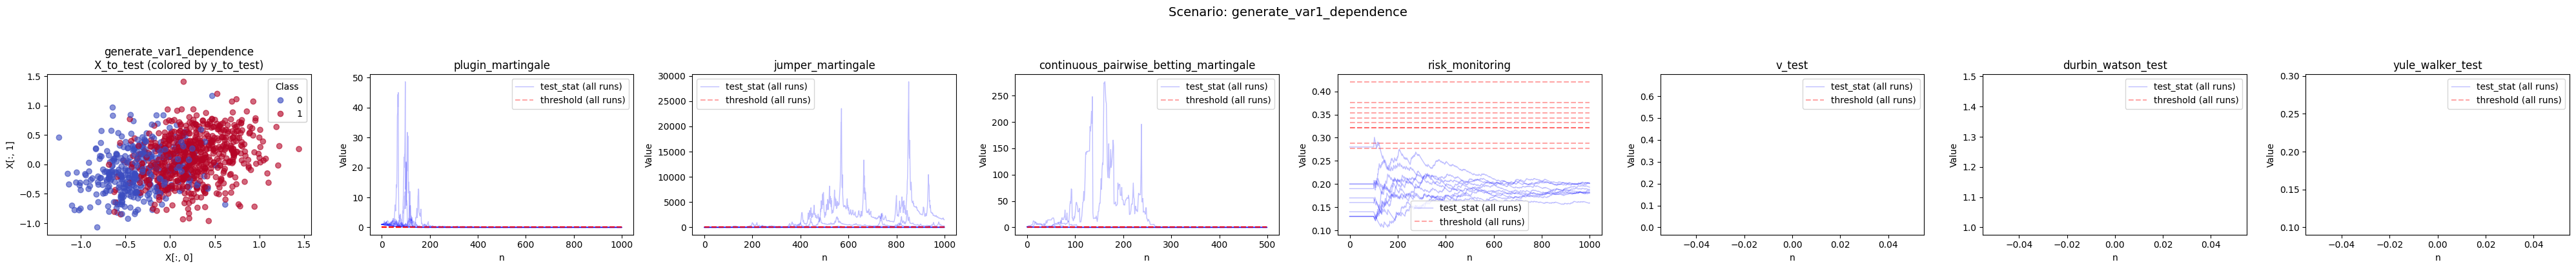

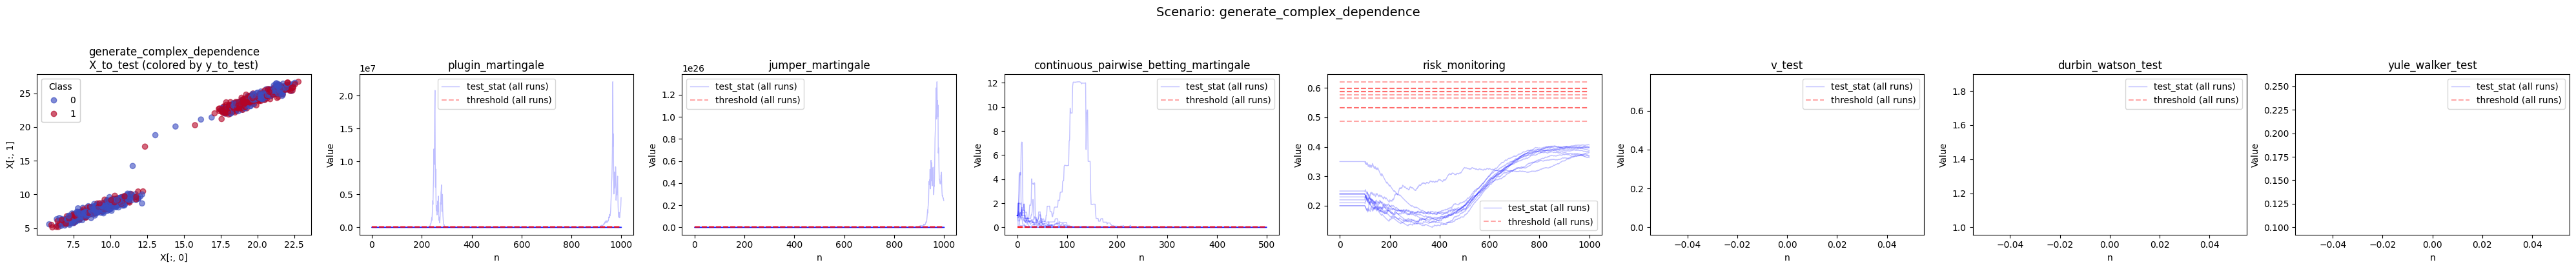

In [5]:
# For plotting, we use scenarios_dict and methods_dict below
# scenarios_dict: {scenario_name: scenario_func}
# methods_dict: {method_name: method_func}

for scenario_name, scenario_func in scenarios_dict.items():
    # Regenerate one sample dataset only for visualization in the first panel.
    res = scenario_func()
    if len(res) == 5:
        is_exchangeable_ground_truth, X_to_test, y_to_test, X_train, y_train = res
    else:
        # fallback, skip plotting
        continue

    df_scenario = df[df["scenario"] == scenario_name]
    method_names = df_scenario["method"].unique()

    n_rows = 1
    n_cols = 1 + len(method_names)
    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4), squeeze=False
    )
    # Plot scenario data in the first column (scatter X_to_test, color by y_to_test)
    ax = axes[0, 0]
    if X_to_test.shape[1] == 2:
        scatter = ax.scatter(X_to_test[:, 0], X_to_test[:, 1], c=y_to_test, cmap="coolwarm", alpha=0.6)
        legend1 = ax.legend(*scatter.legend_elements(), title="Class")
        ax.add_artist(legend1)
    else:
        # Too many dims, just plot first dimension
        ax.scatter(X_to_test[:, 0], np.zeros_like(X_to_test[:, 0]), c=y_to_test, cmap="coolwarm", alpha=0.6)
    ax.set_title(f"{scenario_name}\nX_to_test (colored by y_to_test)")
    ax.set_xlabel("X[:, 0]")
    if X_to_test.shape[1] > 1:
        ax.set_ylabel("X[:, 1]")
    else:
        ax.set_ylabel("")

    # Plot test_stat for all runs and one threshold curve per method
    for j, method_name in enumerate(method_names, start=1):
        ax = axes[0, j]
        df_method = df_scenario[df_scenario["method"] == method_name]

        run_ids = sorted(df_method["run"].unique())
        for run_id in run_ids:
            df_run = df_method[df_method["run"] == run_id].sort_values("n")
            ax.plot(
                df_run["n"].values,
                df_run["test_stat"].values,
                color="blue",
                alpha=0.25,
                linewidth=1,
                label="test_stat (all runs)" if run_id == run_ids[0] else None,
            )
            ax.plot(
                df_run["n"].values,
                df_run["threshold"].values,
                color="red",
                linestyle="--",
                alpha=0.35,
                linewidth=1.5,
                label="threshold (all runs)" if run_id == run_ids[0] else None,
            )
        ax.set_title(f"{method_name}")
        ax.set_xlabel("n")
        ax.set_ylabel("Value")
        ax.legend()
    plt.suptitle(f"Scenario: {scenario_name}", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()